🌍 dataset
📊 analysis
🔎 exploration
🧹 cleaning
💡 insights
📈 trends
📉 comparisons
⚠️ outliers

Soft pink     #FF9AA2
Soft blue     #A0C4FF
Soft green    #B5EAD7
Lavender      #CDB4DB
Soft yellow   #FFF3B0

# 🌍 World Happiness Analysis

In this project, I explore the World Happiness dataset to understand what factors influence happiness levels across different countries.

Using Exploratory Data Analysis (EDA), I analyze variables such as GDP per capita, social support, life expectancy, freedom, generosity, and corruption perception.

The goal of this project is to identify patterns, relationships, and insights that help explain why some countries report higher happiness levels than others.

## 📊 Dataset Overview

The dataset used in this project comes from the World Happiness Report. It contains information about happiness scores over the years (2015–2019) and several factors that may influence well-being in different countriessuch. The features I'm going to explore is:

- **🌍 Country:** The name of the country in the dataset.

- **😊 Score:** The happiness score for each country based on overall life satisfaction.

- **💰 GDP per Capita:** Represents the economic strength of a country.  

- **🤝 Social Support:** Measures how much people feel they have someone they can rely on.

- **🏥 Life Expectancy:** The average number of healthy years a person is expected to live in a country.

- **🕊️ Freedom:** Measures the degree to which people feel they have freedom to make life choices.

- **❤️ Generosity:** Reflects how willing people are to donate money or help others in their society.

- **⚖️ Corruption:** Measures people's perception of corruption in government and public institutions.

Source:(https://www.kaggle.com/datasets/unsdsn/world-happiness)

## 🎯 Project Objectives

In this project, I aim to:

- Analyze global happiness scores across countries
- Identify which factors correlate most strongly with happiness
- Explore trends across multiple years
- Discover interesting patterns and outliers in the data

---------------------------------------

## 📥 Laibraries import

In [137]:
# Import the necessary librareis 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

## 🎨 Visualization Style

To make the visualizations clear and visually appealing, I apply a consistent plotting style across all charts.  
This improves readability and makes patterns in the data easier to understand.

In [101]:
sns.set_theme(style="whitegrid", palette="pastel")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

-------------------------------------

## 📊 Dataset Loading

In [73]:
# Load datasets
df2015 = pd.read_csv("../data/2015.csv")
df2016 = pd.read_csv("../data/2016.csv")
df2017 = pd.read_csv("../data/2017.csv")
df2018 = pd.read_csv("../data/2018.csv")
df2019 = pd.read_csv("../data/2019.csv")

print("Datasets loaded successfully")

Datasets loaded successfully


In [74]:
df2015.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


-----------------------------

## 🔎 Dataset Inspection

Before combining the datasets, I examine the column names for each year.

Different versions of the World Happiness dataset use slightly different naming conventions.  
To combine the data correctly, I first need to understand these differences.

In [75]:
df2015.columns

Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Standard Error', 'Economy (GDP per Capita)', 'Family',
       'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)',
       'Generosity', 'Dystopia Residual'],
      dtype='str')

In [76]:
df2016.columns

Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Lower Confidence Interval', 'Upper Confidence Interval',
       'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)',
       'Freedom', 'Trust (Government Corruption)', 'Generosity',
       'Dystopia Residual'],
      dtype='str')

In [77]:
df2017.columns

Index(['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high',
       'Whisker.low', 'Economy..GDP.per.Capita.', 'Family',
       'Health..Life.Expectancy.', 'Freedom', 'Generosity',
       'Trust..Government.Corruption.', 'Dystopia.Residual'],
      dtype='str')

In [78]:
df2018.columns

Index(['Overall rank', 'Country or region', 'Score', 'GDP per capita',
       'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='str')

In [79]:
df2019.columns

Index(['Overall rank', 'Country or region', 'Score', 'GDP per capita',
       'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='str')

---------------------------

## 🧹 Standardizing Column Names

The World Happiness datasets use different column names across years.

For example, some datasets use **Happiness Score** while others use **Score**.  
To combine the datasets properly, I rename the columns so they follow a consistent format.

This will allow me to merge all years into one dataset for easier analysis.

# 2015

In [80]:
df2015 = df2015.rename(columns={
    'Country':'country',
    'Happiness Score':'score',
    'Economy (GDP per Capita)':'gdp',
    'Family':'social_support',
    'Health (Life Expectancy)':'life_expectancy',
    'Freedom':'freedom',
    'Trust (Government Corruption)':'corruption',
    'Generosity':'generosity'
})

# 2016

In [81]:
df2016 = df2016.rename(columns={
    'Country':'country',
    'Happiness Score':'score',
    'Economy (GDP per Capita)':'gdp',
    'Family':'social_support',
    'Health (Life Expectancy)':'life_expectancy',
    'Freedom':'freedom',
    'Trust (Government Corruption)':'corruption',
    'Generosity':'generosity'
})

# 2017

In [82]:
df2017 = df2017.rename(columns={
    'Country':'country',
    'Happiness.Score':'score',
    'Economy..GDP.per.Capita.':'gdp',
    'Family':'social_support',
    'Health..Life.Expectancy.':'life_expectancy',
    'Freedom':'freedom',
    'Trust..Government.Corruption.':'corruption',
    'Generosity':'generosity'
})

# 2018

In [83]:
df2018 = df2018.rename(columns={
    'Country or region':'country',
    'Score':'score',
    'GDP per capita':'gdp',
    'Social support':'social_support',
    'Healthy life expectancy':'life_expectancy',
    'Freedom to make life choices':'freedom',
    'Perceptions of corruption':'corruption',
    'Generosity':'generosity'
})

# 2019

In [84]:
df2019 = df2019.rename(columns={
    'Country or region':'country',
    'Score':'score',
    'GDP per capita':'gdp',
    'Social support':'social_support',
    'Healthy life expectancy':'life_expectancy',
    'Freedom to make life choices':'freedom',
    'Perceptions of corruption':'corruption',
    'Generosity':'generosity'
})

In [85]:
# Add a year column in each dataset
df2015["year"] = 2015
df2016["year"] = 2016
df2017["year"] = 2017
df2018["year"] = 2018
df2019["year"] = 2019

In [86]:
# Compine all datasets in one
df = pd.concat([df2015, df2016, df2017, df2018, df2019], ignore_index=True)

In [87]:
df.head()

,country,Region,Happiness Rank,score,Standard Error,gdp,social_support,life_expectancy,freedom,corruption,generosity,Dystopia Residual,year,Lower Confidence Interval,Upper Confidence Interval,Happiness.Rank,Whisker.high,Whisker.low,Dystopia.Residual,Overall rank
0,Switzerland,Western Europe,1.0,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Iceland,Western Europe,2.0,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Denmark,Western Europe,3.0,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Norway,Western Europe,4.0,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Canada,North America,5.0,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--------------------------------------

## 🧹 Feature Selection

After merging the datasets, some columns appeared with many missing values.  
These columns exist only in certain years and are not required for the main analysis.

To simplify the dataset, I keep only the key variables related to happiness and its main contributing factors.

In [88]:
df = df[[
    "country",
    "score",
    "gdp",
    "social_support",
    "life_expectancy",
    "freedom",
    "generosity",
    "corruption",
    "year"
]]

In [89]:
# Lets check the head again.
df.head()

,country,score,gdp,social_support,life_expectancy,freedom,generosity,corruption,year
0,Switzerland,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978,2015
1,Iceland,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145,2015
2,Denmark,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357,2015
3,Norway,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503,2015
4,Canada,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957,2015


In [90]:
# Now we have only the important columns
df.columns

Index(['country', 'score', 'gdp', 'social_support', 'life_expectancy',
       'freedom', 'generosity', 'corruption', 'year'],
      dtype='str')

----------------------------------------

## 🔎 Basic Exploration

In [91]:
df.shape

(782, 9)

In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          782 non-null    str    
 1   score            782 non-null    float64
 2   gdp              782 non-null    float64
 3   social_support   782 non-null    float64
 4   life_expectancy  782 non-null    float64
 5   freedom          782 non-null    float64
 6   generosity       782 non-null    float64
 7   corruption       781 non-null    float64
 8   year             782 non-null    int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 55.1 KB


In [93]:
df.describe()

,score,gdp,social_support,life_expectancy,freedom,generosity,corruption,year
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,781.000000,782.000000
mean,5.379018,0.916047,1.078392,0.612416,0.411091,0.218576,0.125436,2016.993606
std,1.127456,0.407340,0.329548,0.248309,0.152880,0.122321,0.105816,1.417364
min,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2015.000000
25%,4.509750,0.606500,0.869363,0.440183,0.309768,0.130000,0.054000,2016.000000
50%,5.322000,0.982205,1.124735,0.647310,0.431000,0.201982,0.091000,2017.000000
75%,6.189500,1.236187,1.327250,0.808000,0.531000,0.278832,0.156030,2018.000000
max,7.769000,2.096000,1.644000,1.141000,0.724000,0.838075,0.551910,2019.000000


In [94]:
df.isnull().sum()

country            0
score              0
gdp                0
social_support     0
life_expectancy    0
freedom            0
generosity         0
corruption         1
year               0
dtype: int64

-------------------------------------------------

## 🧹 Handling Missing Values

After checking the dataset, I found that only **one value is missing** in the `corruption` column.

Since the dataset contains hundreds of rows, this missing value represents **far less than 5% of the data**.

Therefore, I remove this row to maintain data quality without affecting the analysis.

In [95]:
# Drop missing data
df = df.dropna()

In [96]:
# Verify
df.isnull().sum()

country            0
score              0
gdp                0
social_support     0
life_expectancy    0
freedom            0
generosity         0
corruption         0
year               0
dtype: int64

--------------------------------------------------
----------------------------------------------------------

## 🔎 Exploratory Data Analysis (EDA)

In this section, I explore the dataset to discover patterns, relationships, and trends related to global happiness.

The analysis will include:

- Distribution of happiness scores
- Comparison of happiest countries
- Relationships between happiness and economic or social factors
- Correlation between variables

-----------------------------

### 📊 Distribution of Key Variables

To better understand the dataset, I explore the distribution of the main variables that may influence happiness.

These distributions help reveal:

- How values are spread across countries
- Whether the variables are normally distributed
- Possible skewness or outliers in the data

Understanding these distributions provides important context before exploring relationships between variables.

In [103]:
df.head(
)

,country,score,gdp,social_support,life_expectancy,freedom,generosity,corruption,year
0,Switzerland,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978,2015
1,Iceland,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145,2015
2,Denmark,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357,2015
3,Norway,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503,2015
4,Canada,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957,2015


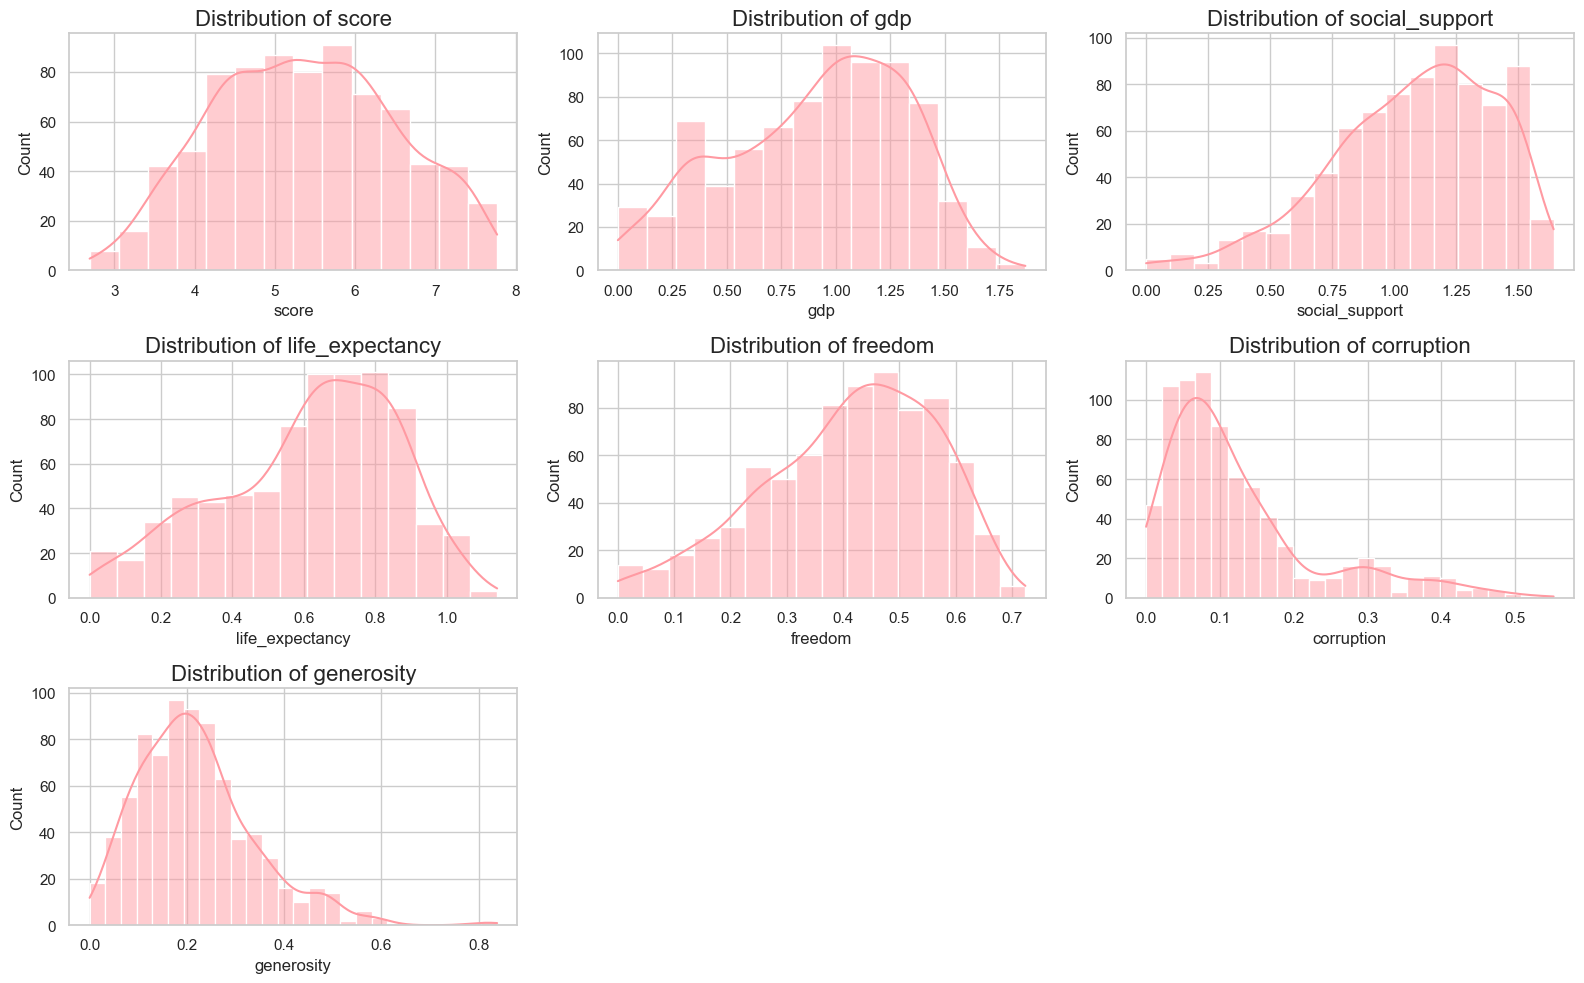

In [104]:
numeric_variable = ["score" , "gdp" , "social_support" , "life_expectancy" , "freedom" , "corruption" , "generosity"]

plt.figure(figsize=(16, 10))
for i, col in enumerate(numeric_variable, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, color="#FF9AA2")
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

💡 **Insights**

- Happiness scores are mostly concentrated in the middle range, suggesting that most countries report moderate levels of happiness.
- GDP and social support show relatively smooth distributions, indicating variation in economic and social conditions across countries.
- Generosity and corruption appear more skewed, meaning most countries have lower values while only a few have high values.

--------

### 🌟 Top 5 Happiest Countries

This chart shows the countries with the highest average happiness scores between **2015 and 2019**.

By averaging the scores across multiple years, it highlights countries that consistently rank among the happiest in the world.

C:\Users\ragha\AppData\Local\Temp\ipykernel_12228\2357983885.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


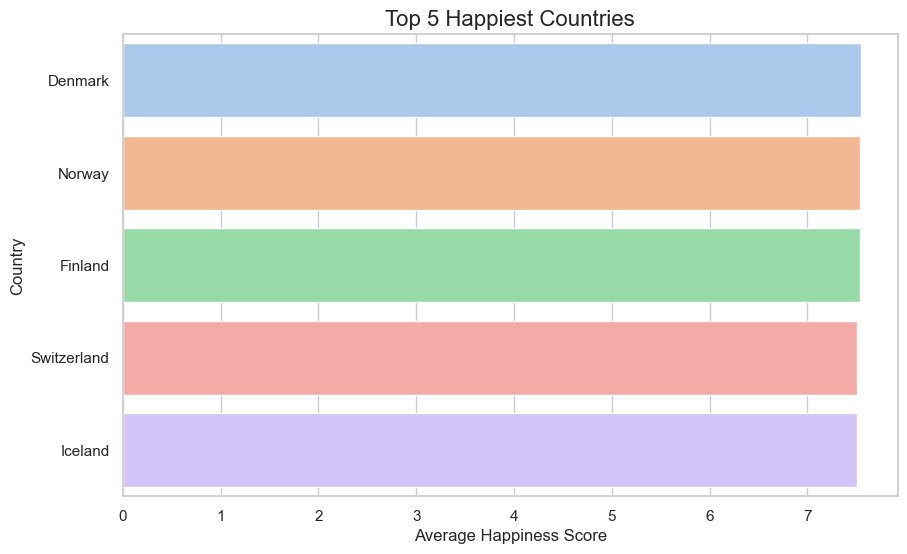

In [128]:
top5 = (
    df.groupby("country")["score"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top5,
    x="score",
    y="country",
    palette="pastel"
)

plt.title("Top 5 Happiest Countries")
plt.xlabel("Average Happiness Score")
plt.ylabel("Country")

plt.show()

💡 **Insights**

Denmark, Norway, and Finland appear at the top with very similar happiness scores, all above approximately 7.5. Switzerland and Iceland follow closely behind with slightly lower but still very high scores.

The small differences between the bars indicate that these countries maintain consistently high levels of happiness. This suggests that nations with strong social systems, high standards of living, and stable institutions tend to achieve higher overall life satisfaction.

--------------

### 📉 Lowest 5 Happiness Score Countries

This chart highlights the countries with the lowest average happiness scores between **2015 and 2019**.

Examining these countries helps identify regions where people report lower levels of life satisfaction.

C:\Users\ragha\AppData\Local\Temp\ipykernel_12228\775408963.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


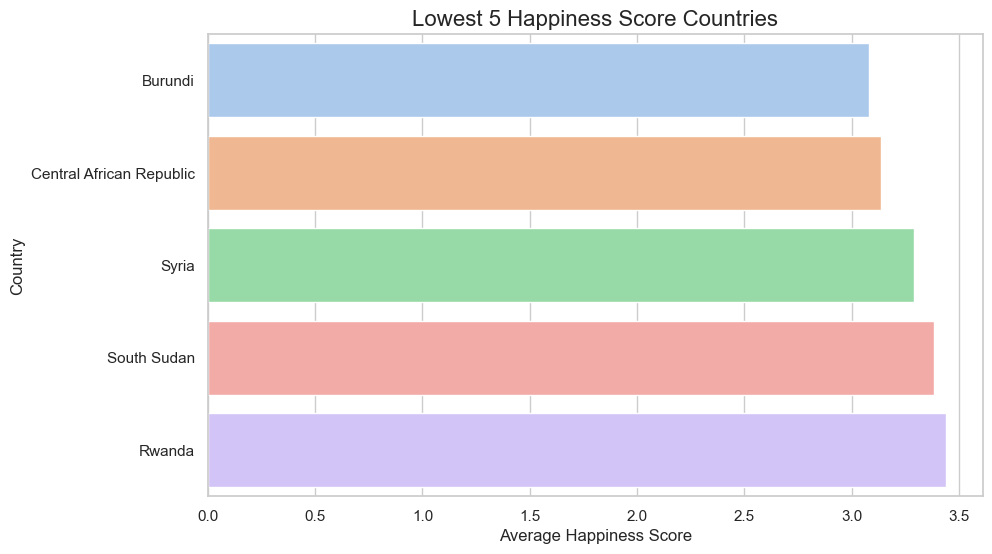

In [129]:
lowest5 = (
    df.groupby("country")["score"]
    .mean()
    .sort_values()
    .head(5)
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=lowest5,
    x="score",
    y="country",
    palette="pastel"
)

plt.title("Lowest 5 Happiness Score Countries")
plt.xlabel("Average Happiness Score")
plt.ylabel("Country")

plt.show()

💡 **Insights**

Burundi and the Central African Republic have the lowest happiness scores, both close to 3.0, indicating very low levels of reported life satisfaction. Syria, South Sudan, and Rwanda also appear in this group with slightly higher but still low happiness scores.

The difference between these countries and the happiest nations is significant, highlighting a large global gap in well-being. Many of these countries face economic difficulties, political instability, or social challenges that may negatively affect overall happiness.

------------------------------------------

### 📈 Happiness Score Trend of the Top Countries

To understand how happiness changes over time, I examine the trend of happiness scores for the top countries in the dataset.

This visualization shows whether the happiest countries maintain their positions consistently across the years 2015–2019.

Tracking these trends helps reveal:

- Stability in national happiness levels
- Countries that improve or decline over time
- Long-term patterns among the happiest nations

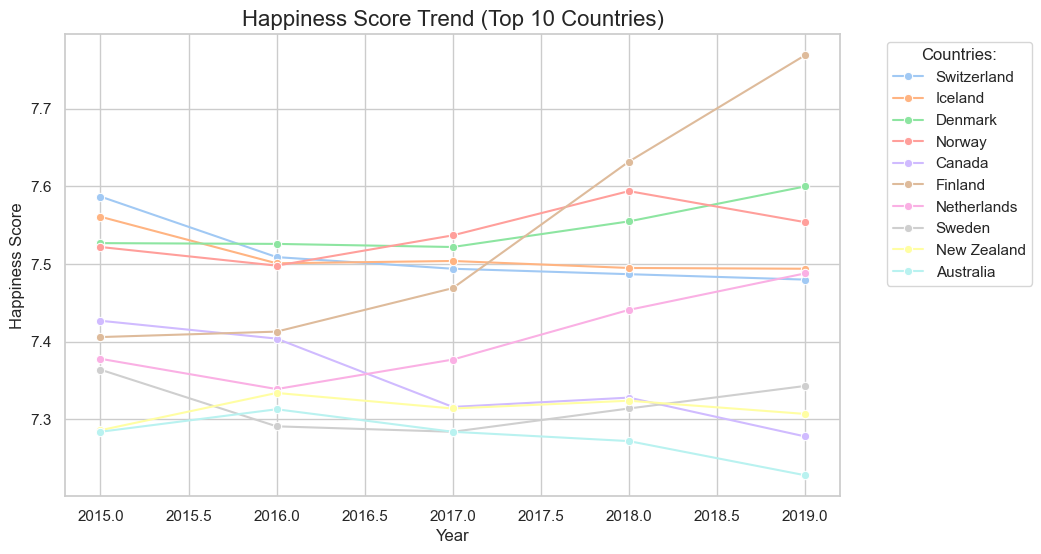

In [108]:
# Find the top 10 happiest countries based on average score
top_countries = (
    df.groupby("country")["score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Filter data for these countries
top_df = df[df["country"].isin(top_countries)]

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=top_df,
    x="year",
    y="score",
    hue="country",
    marker="o",
    palette="pastel"
)

plt.title("Happiness Score Trend (Top 10 Countries)")
plt.xlabel("Year")
plt.ylabel("Happiness Score")
plt.legend(title="Countries:", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

💡 **Insights**

The chart shows that the top happiest countries maintain relatively stable happiness scores between 2015 and 2019, with only small fluctuations over time.

Finland displays the most noticeable upward trend, increasing steadily and reaching the highest score by 2019. Denmark and Norway remain consistently high with only minor variations across the years.

Most of the other countries show very small changes in their scores, indicating that happiness levels among the top-ranked nations tend to remain stable rather than changing dramatically over time.

------------------

### 📦 Happiness Score Distribution by Year

This boxplot shows how happiness scores are distributed for each year.

It helps identify changes in the spread of happiness across years and highlights potential outliers within each year.

C:\Users\ragha\AppData\Local\Temp\ipykernel_12228\2295863031.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


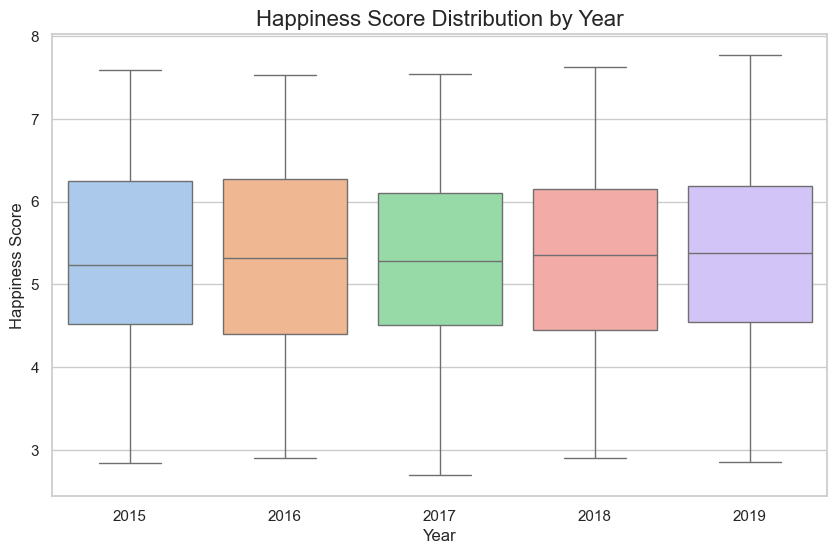

In [125]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="year",
    y="score",
    palette="pastel"
)

plt.title("Happiness Score Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Happiness Score")

plt.show()

💡 Insight

The median happiness score remains fairly consistent across the years, suggesting that global happiness levels did not change dramatically during this period.

------------

### 💰 GDP vs Happiness Score

This visualization explores the relationship between a country's economic strength and its happiness level.

GDP per capita is often considered an important factor influencing well-being, as higher income levels may provide better living conditions, healthcare, and opportunities.

By examining this relationship, I can see whether wealthier countries tend to report higher happiness scores.

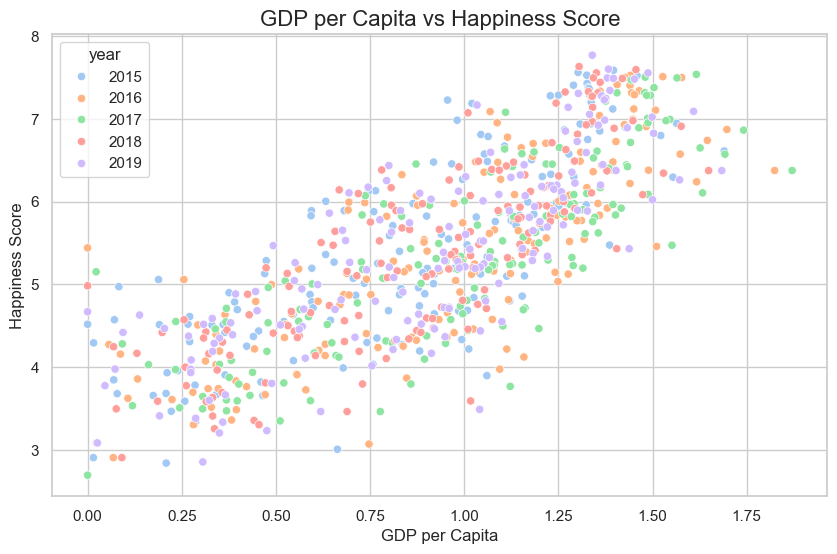

In [112]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="gdp",
    y="score",
    hue="year",
    palette="pastel"
)

plt.title("GDP per Capita vs Happiness Score")
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")

plt.show()

💡 Insight

The scatter plot suggests a positive relationship between GDP per capita and happiness score.

Countries with higher economic prosperity generally report higher levels of happiness, although wealth alone does not fully explain happiness differences between countries.

-----------------------

### 🤝 Social Support vs Happiness

Social support measures whether people feel they have someone they can rely on in times of need.

This visualization explores how the level of social support in a country relates to its happiness score.

Strong social connections may contribute to higher well-being and life satisfaction.

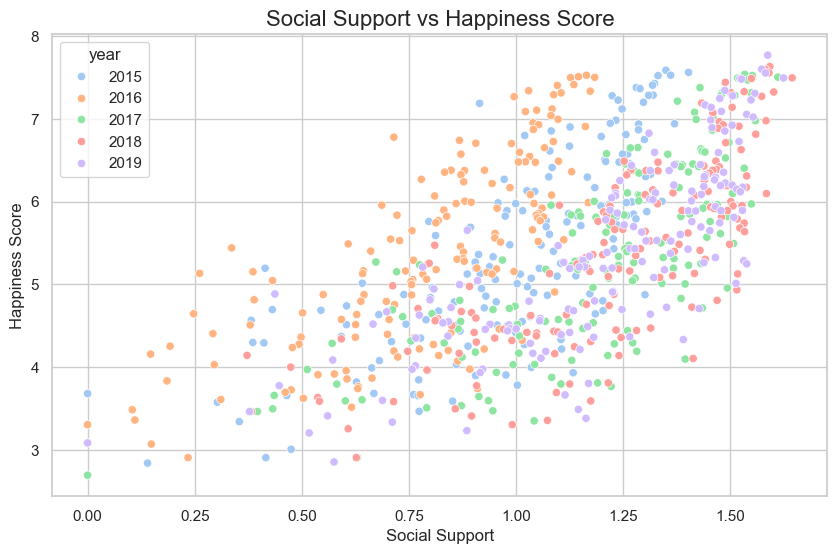

In [116]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="social_support",
    y="score",
    hue="year",
    palette="pastel"
)

plt.title("Social Support vs Happiness Score")
plt.xlabel("Social Support")
plt.ylabel("Happiness Score")

plt.show()

💡 **Insight**

Countries with stronger social support networks generally report higher happiness scores.  
This suggests that having reliable relationships and community support plays an important role in overall well-being.

------------------

### 🕊️ Freedom vs Happiness

Freedom reflects people's perception of their ability to make life choices.

This plot examines whether countries with higher levels of freedom tend to have higher happiness scores.

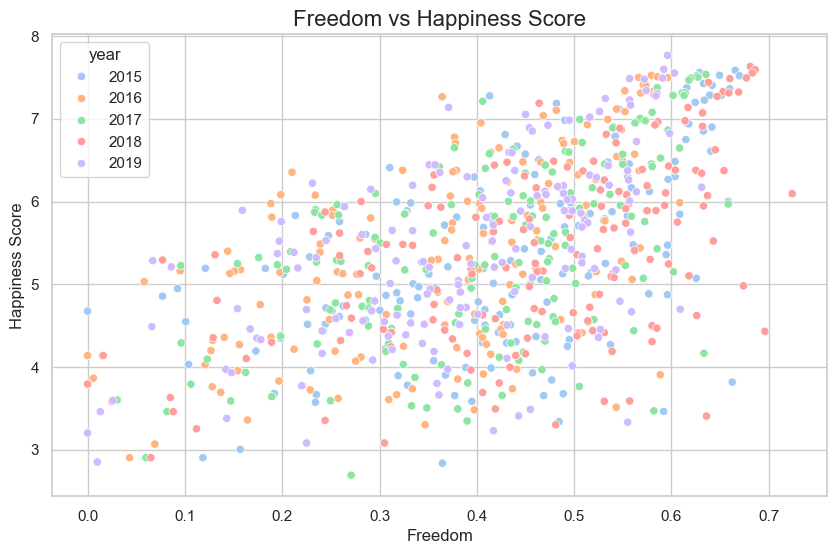

In [118]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="freedom",
    y="score",
    hue="year",
    palette="pastel"
)

plt.title("Freedom vs Happiness Score")
plt.xlabel("Freedom")
plt.ylabel("Happiness Score")

plt.show()

💡 **Insight**

The plot suggests a positive relationship between freedom and happiness.  
Countries where individuals feel more free to make life choices often report higher levels of happiness.

---------------------------

### 🔥 Correlation Between Happiness Factors

To better understand how different variables relate to each other, I compute a correlation matrix.

This heatmap shows the strength and direction of relationships between the main variables in the dataset.

It helps identify which factors are most strongly associated with happiness scores.

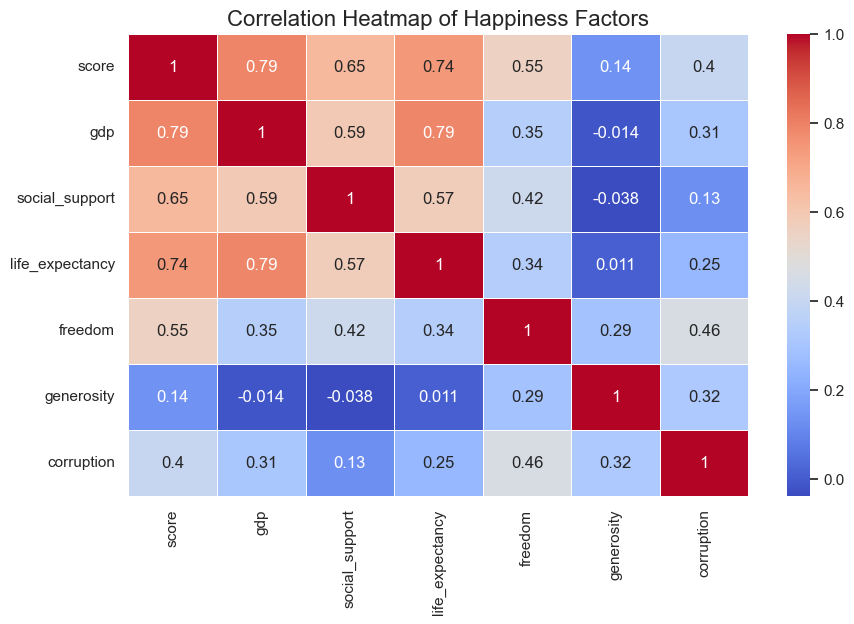

In [119]:
plt.figure(figsize=(10,6))

corr = df[[
    "score",
    "gdp",
    "social_support",
    "life_expectancy",
    "freedom",
    "generosity",
    "corruption"
]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Happiness Factors")

plt.show()

💡 **Insights**

The heatmap reveals how strongly each factor relates to happiness.

GDP per capita, social support, and life expectancy show strong positive correlations with happiness score.

This suggests that economic stability, strong social networks, and good health conditions are important contributors to overall well-being.

------------------------

### 📊 Average Global Happiness Over Time

To understand how happiness changes globally, I calculate the average happiness score for each year.

This visualization helps identify whether overall happiness levels increase, decrease, or remain stable between 2015 and 2019.

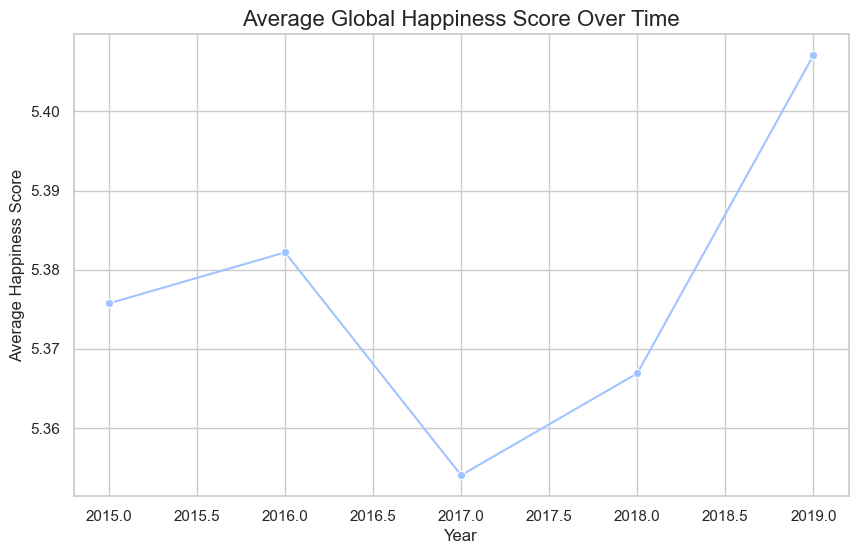

In [120]:
avg_happiness = df.groupby("year")["score"].mean().reset_index()

plt.figure(figsize=(10,6))

sns.lineplot(
    data=avg_happiness,
    x="year",
    y="score",
    marker="o",
    color="#A0C4FF"
)

plt.title("Average Global Happiness Score Over Time")
plt.xlabel("Year")
plt.ylabel("Average Happiness Score")

plt.show()

💡 **Insight**

The chart shows that the global average happiness score remains relatively stable between 2015 and 2019, with only small fluctuations over time.

There is a noticeable drop in the average score around 2017, followed by a gradual recovery in 2018 and a stronger increase by 2019, which reaches the highest average happiness level in the observed period.

This pattern suggests that while global happiness does not change dramatically from year to year, small variations can occur due to economic conditions, social factors, or political events that influence well-being across multiple countries.

---------------------

### 🔎 Relationships Between Happiness Factors

To summarizes and further explore the relationships between the key variables in the dataset, I use a pairplot.

This visualization displays pairwise relationships between happiness score and the main contributing factors, including GDP, social support, life expectancy, freedom, generosity, and corruption.

It helps identify patterns, correlations, and possible trends between these variables.

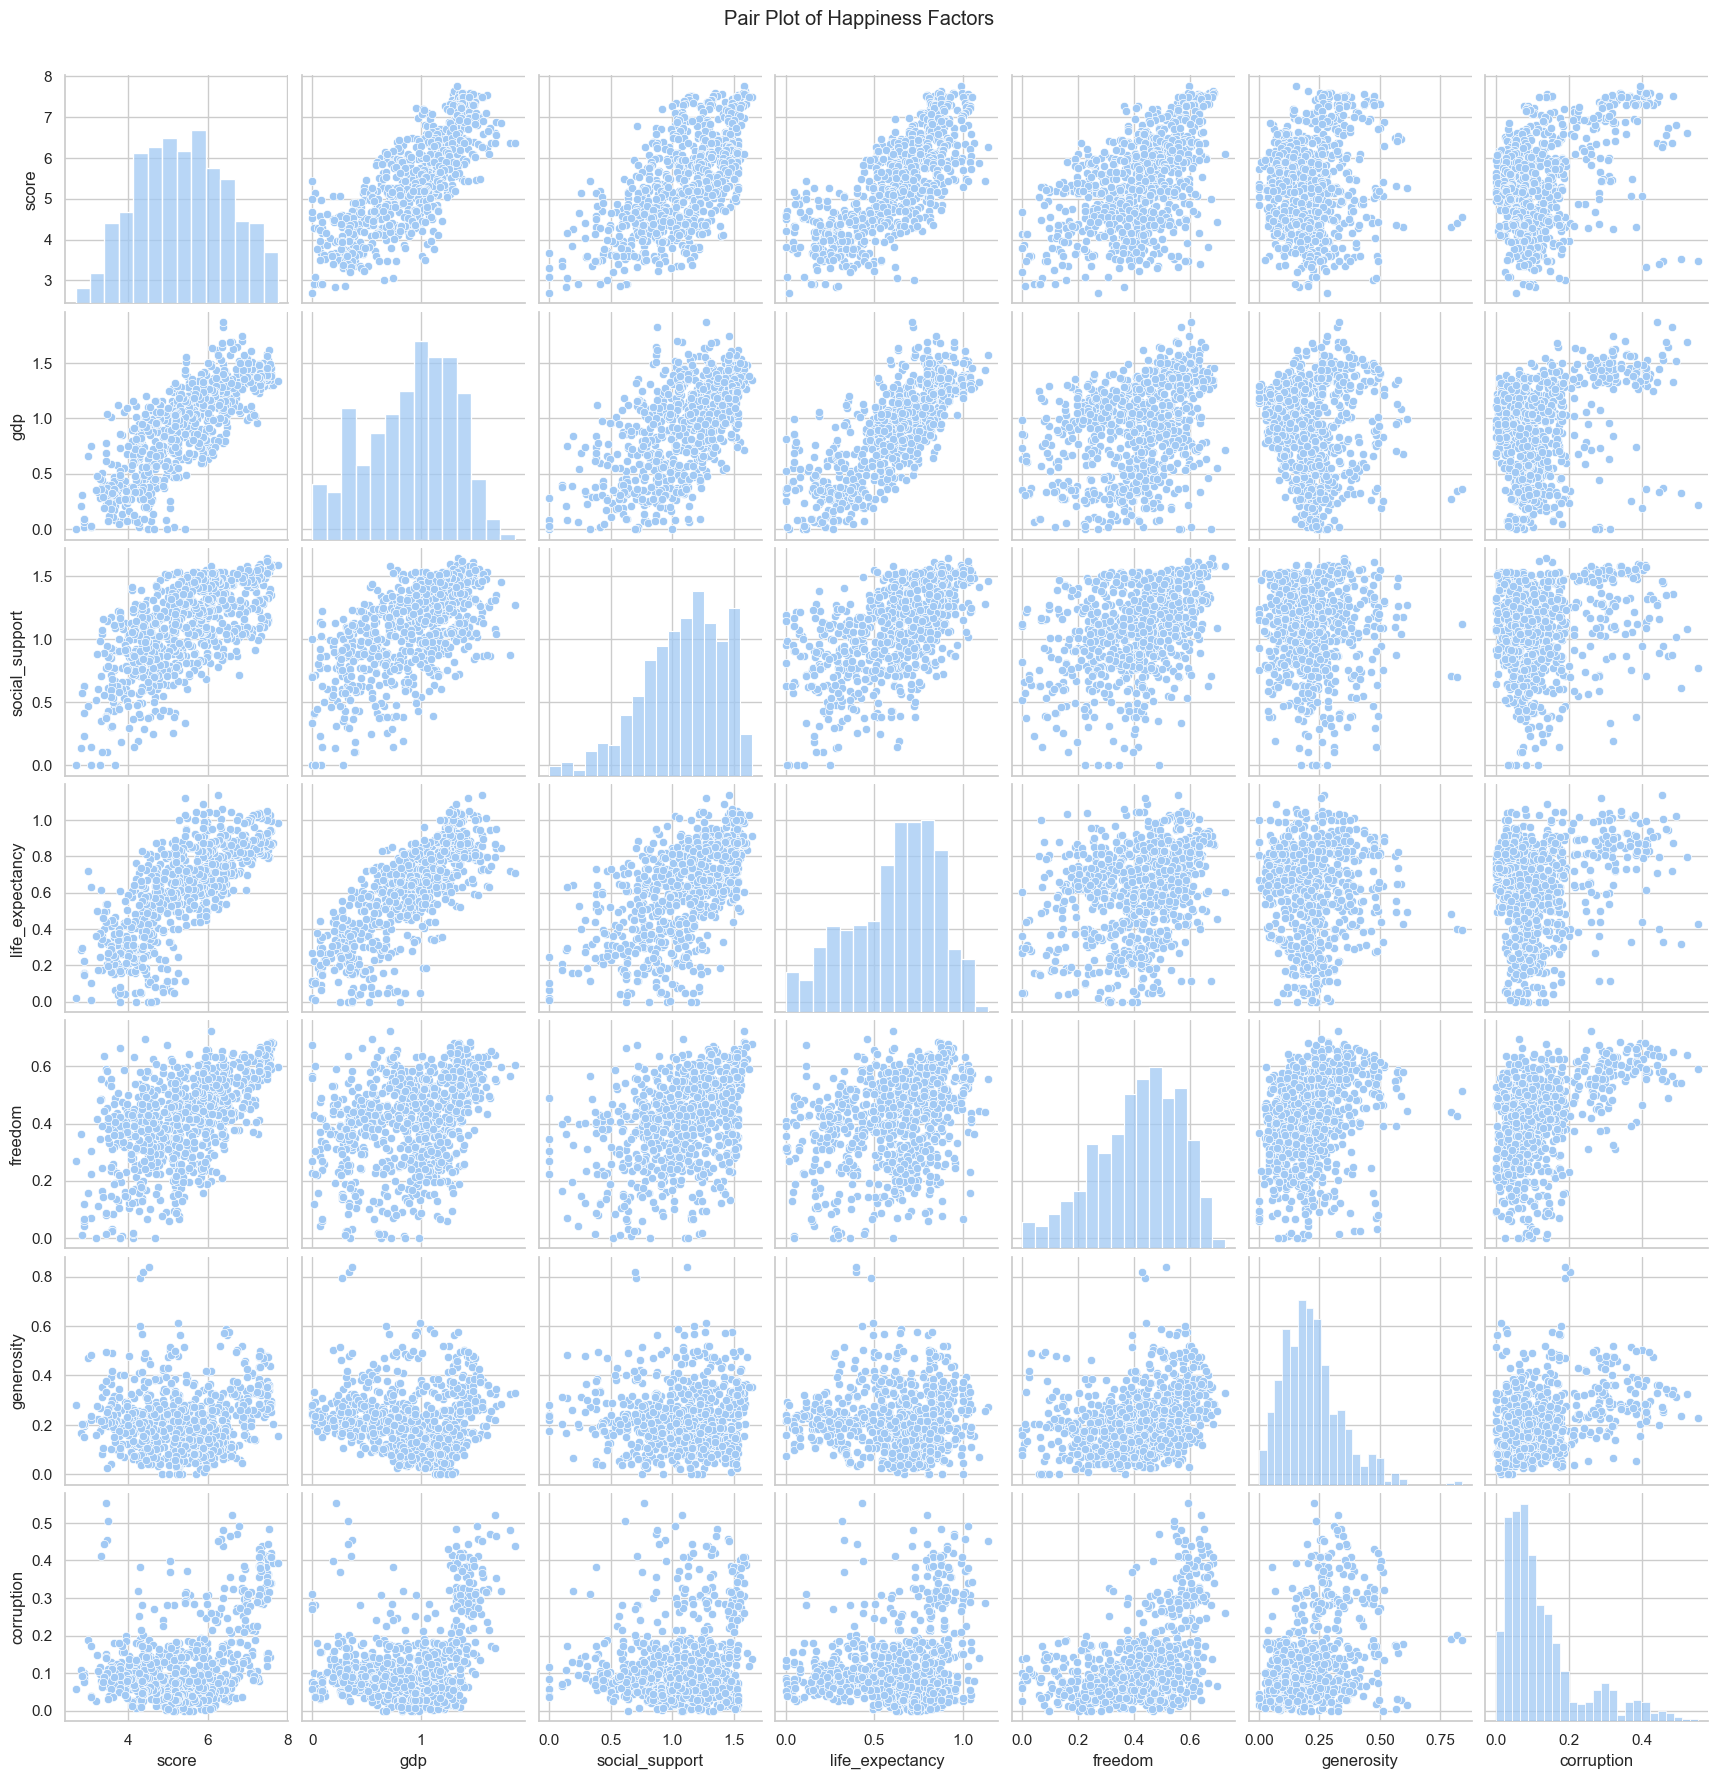

In [134]:
pair_plot = sns.pairplot(
    df[
        [
            "score",
            "gdp",
            "social_support",
            "life_expectancy",
            "freedom",
            "generosity",
            "corruption"
        ]
    ]
)

pair_plot.fig.suptitle("Pair Plot of Happiness Factors", y=1.02)

plt.show()

💡 Insight

The pair plot shows clear positive relationships between happiness score and factors such as GDP, social support, and life expectancy. Countries with higher values in these variables tend to report higher happiness scores.

In contrast, generosity and corruption show weaker and less consistent relationships with happiness, suggesting that their effect may be smaller or more complex.

----------------------------
-----------------------

## 🤖 Predicting Happiness Score

After exploring the dataset through EDA, I build a simple regression model to predict happiness scores based on the main contributing factors.

The model uses the following features:

- GDP per capita
- Social support
- Life expectancy
- Freedom
- Generosity
- Perception of corruption

The goal is to evaluate how well these factors can predict a country's happiness score.

-----------------

### 📊 Preparing the Data

To build the predictive model, I divide the dataset into features and a target variable.

The happiness score is used as the target variable, while the remaining factors such as GDP, social support, life expectancy, freedom, generosity, and corruption are used as input features for the model.

In [136]:
X = df[
    [
        "gdp",
        "social_support",
        "life_expectancy",
        "freedom",
        "generosity",
        "corruption"
    ]
]

y = df["score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

---------------

### 🤖 Training the Model

To predict happiness scores, I train a Linear Regression model using the selected features.

The model learns the relationship between the happiness score and the different factors that influence well-being.

In [138]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


------------

### 🔮 Making Predictions

After training the model, I use the test dataset to generate predicted happiness scores.

These predictions represent the model’s estimated happiness values based on the input features.

In [139]:
y_pred = model.predict(X_test)

--------------

### 📏 Evaluating the Model

To evaluate the performance of the model, I calculate two common regression metrics: Mean Absolute Error (MAE) and the R² score.

MAE represents the average difference between the predicted happiness score and the actual value. A lower MAE indicates better prediction accuracy.

The R² score measures how well the model explains the variation in happiness scores. Values closer to 1 indicate that the model captures a larger portion of the relationship between the input features and happiness.

In [140]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R² Score:", r2)

MAE: 0.43066600242687986
R² Score: 0.7465230243518592


💡 Interpretation

The model is able to capture the general relationship between the selected factors and the happiness score. 

The MAE value indicates that the average prediction error is relatively small, meaning the model’s predictions are reasonably close to the true happiness scores.

The R² score suggests that a substantial portion of the variation in happiness can be explained by factors such as GDP, social support, life expectancy, freedom, generosity, and corruption.

--------------

### 📉 Actual vs Predicted Happiness

To visually evaluate the model's performance, I compare the predicted happiness scores with the actual values.

If the predictions are accurate, the points should appear close to a diagonal pattern.

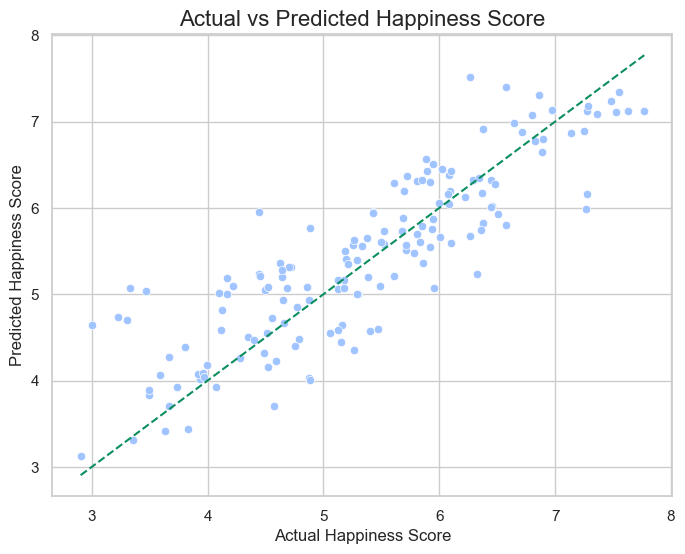

In [144]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    color="#A0C4FF"
)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color=  "#0B8E5E",
         linestyle="--")

plt.xlabel("Actual Happiness Score")
plt.ylabel("Predicted Happiness Score")
plt.title("Actual vs Predicted Happiness Score")

plt.show()

💡 Insight

The scatter plot shows that the predicted happiness scores generally follow the same pattern as the actual values. Most points appear close to the diagonal reference line, indicating that the model captures the overall relationship between the input features and the happiness score reasonably well.

------------
--------------

## 📌 Summary of Findings

In this project, I explored the World Happiness dataset to understand the factors that influence happiness across countries.

Through exploratory data analysis, I observed strong relationships between happiness and variables such as GDP, social support, and life expectancy.

The regression model also showed that these factors can reasonably predict happiness scores, suggesting that economic conditions, social support systems, and health levels play an important role in overall well-being.